---
Phase 4-CV-1: CNN 卷積神經網路 — 從零理解
---

MLP 看圖片的問題：
  28×28 的圖片展平成 784 → 完全丟失了空間結構
  而且參數量爆炸：784 × 256 = 200K 參數（只有一層！）

CNN 的解法：
  用「卷積核」在圖片上滑動，捕捉局部特徵（邊緣、紋理）
  然後逐層提取更高級的特徵（角、形狀、物體部件）

本檔涵蓋：
  1. 卷積運算的原理 (NumPy 手刻)
  2. Pooling 池化
  3. PyTorch CNN 實作
  4. 特徵圖視覺化
  5. 在 MNIST 上訓練 CNN

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ============================================================================
# 1. 卷積運算 — NumPy 手刻
# ============================================================================

1. 卷積運算 — 卷積核在圖片上滑動

卷積核 (Kernel/Filter)：一個小矩陣（如 3×3）
滑動窗口：卷積核在圖片上從左到右、從上到下滑動
每個位置：卷積核和圖片的對應區域做逐元素乘法後加總

  圖片 (5×5)    卷積核 (3×3)    輸出 (3×3)
  ┌─────────┐   ┌───────┐       ┌───────┐
  │ . . . . .│   │ a b c │       │ . . . │
  │ . . . . .│ * │ d e f │   =   │ . . . │
  │ . . . . .│   │ g h i │       │ . . . │
  │ . . . . .│   └───────┘       └───────┘
  │ . . . . .│
  └─────────┘
  輸出大小 = (5-3+1) × (5-3+1) = 3×3



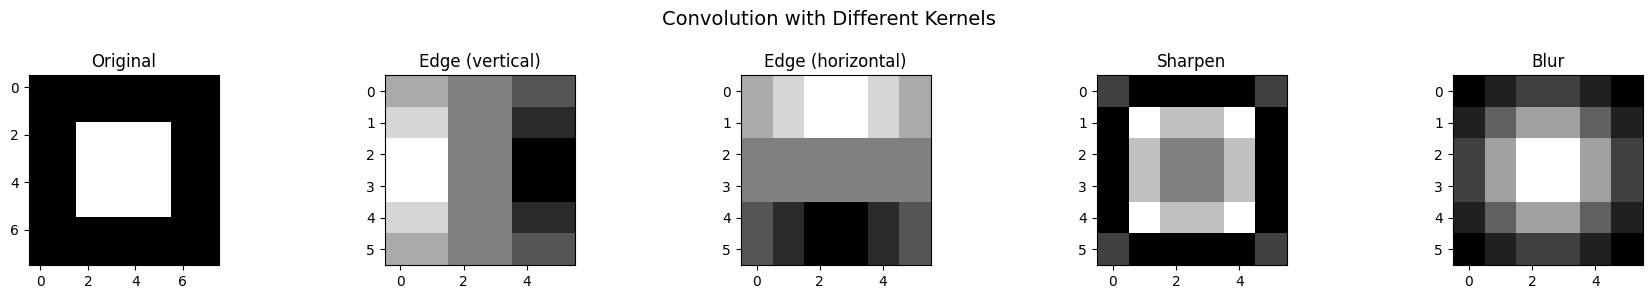

→ 圖表儲存至 cv/plots/01_conv_kernels.png
  不同卷積核偵測不同的特徵（邊緣、模糊等）
  CNN 會自動學習最有用的卷積核！


In [2]:
print("=" * 60)
print("1. 卷積運算 — 卷積核在圖片上滑動")
print("=" * 60)

print("""
卷積核 (Kernel/Filter)：一個小矩陣（如 3×3）
滑動窗口：卷積核在圖片上從左到右、從上到下滑動
每個位置：卷積核和圖片的對應區域做逐元素乘法後加總

  圖片 (5×5)    卷積核 (3×3)    輸出 (3×3)
  ┌─────────┐   ┌───────┐       ┌───────┐
  │ . . . . .│   │ a b c │       │ . . . │
  │ . . . . .│ * │ d e f │   =   │ . . . │
  │ . . . . .│   │ g h i │       │ . . . │
  │ . . . . .│   └───────┘       └───────┘
  │ . . . . .│
  └─────────┘
  輸出大小 = (5-3+1) × (5-3+1) = 3×3
""")


def conv2d_numpy(image, kernel):
    """NumPy 手刻 2D 卷積"""
    h, w = image.shape
    kh, kw = kernel.shape
    out_h = h - kh + 1
    out_w = w - kw + 1
    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            # 取出圖片的對應區域
            region = image[i:i + kh, j:j + kw]
            # 逐元素乘法後加總
            output[i, j] = np.sum(region * kernel)

    return output


# 建立一個簡單的圖片
np.random.seed(42)
image = np.zeros((8, 8))
image[2:6, 2:6] = 1.0     # 中間是一個白色方塊

# 不同的卷積核
kernels = {
    'Edge (vertical)': np.array([[-1, 0, 1],
                                  [-1, 0, 1],
                                  [-1, 0, 1]], dtype=float),
    'Edge (horizontal)': np.array([[-1, -1, -1],
                                    [0,  0,  0],
                                    [1,  1,  1]], dtype=float),
    'Sharpen': np.array([[0, -1, 0],
                          [-1, 5, -1],
                          [0, -1, 0]], dtype=float),
    'Blur': np.ones((3, 3)) / 9,
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')

for i, (name, kernel) in enumerate(kernels.items()):
    result = conv2d_numpy(image, kernel)
    axes[i + 1].imshow(result, cmap='gray')
    axes[i + 1].set_title(name)

plt.suptitle('Convolution with Different Kernels', fontsize=14)
plt.tight_layout()
plt.savefig('phase-4-domains/cv/plots/01_conv_kernels.png', dpi=100)
plt.show()
print("→ 圖表儲存至 cv/plots/01_conv_kernels.png")
print("  不同卷積核偵測不同的特徵（邊緣、模糊等）")
print("  CNN 會自動學習最有用的卷積核！")

## 2. Padding 和 Stride

In [3]:
print("\n" + "=" * 60)
print("2. Padding 和 Stride")
print("=" * 60)

print("""
輸出大小公式：
  output_size = (input_size - kernel_size + 2 × padding) / stride + 1

Padding:
  在圖片周圍補 0，讓輸出和輸入一樣大
  padding=1 + kernel=3 → 輸出大小不變（最常用！）

Stride:
  卷積核每次移動幾格
  stride=2 → 輸出大小減半（取代 Pooling 的另一種方式）
""")

# PyTorch 的卷積層
conv = nn.Conv2d(
    in_channels=1,       # 輸入通道數（灰度=1, RGB=3）
    out_channels=16,     # 輸出通道數（= 卷積核數量 = 學到的特徵數）
    kernel_size=3,       # 卷積核大小
    stride=1,            # 步長
    padding=1,           # 邊界填充
)

# 看參數
print(f"Conv2d 參數:")
print(f"  權重 shape: {conv.weight.shape}")    # (16, 1, 3, 3)
print(f"  → 16 個卷積核，每個 1×3×3")
print(f"  偏差 shape: {conv.bias.shape}")       # (16,)
print(f"  參數量: {sum(p.numel() for p in conv.parameters())}")

# 不同 padding/stride 的效果
x = torch.randn(1, 1, 28, 28)     # (batch, channels, H, W)
print(f"\n輸入: {x.shape}")

for pad, stride in [(0, 1), (1, 1), (0, 2), (1, 2)]:
    c = nn.Conv2d(1, 16, 3, stride=stride, padding=pad)
    out = c(x)
    print(f"  padding={pad}, stride={stride} → 輸出: {out.shape}")


2. Padding 和 Stride

輸出大小公式：
  output_size = (input_size - kernel_size + 2 × padding) / stride + 1

Padding:
  在圖片周圍補 0，讓輸出和輸入一樣大
  padding=1 + kernel=3 → 輸出大小不變（最常用！）

Stride:
  卷積核每次移動幾格
  stride=2 → 輸出大小減半（取代 Pooling 的另一種方式）

Conv2d 參數:
  權重 shape: torch.Size([16, 1, 3, 3])
  → 16 個卷積核，每個 1×3×3
  偏差 shape: torch.Size([16])
  參數量: 160

輸入: torch.Size([1, 1, 28, 28])
  padding=0, stride=1 → 輸出: torch.Size([1, 16, 26, 26])
  padding=1, stride=1 → 輸出: torch.Size([1, 16, 28, 28])
  padding=0, stride=2 → 輸出: torch.Size([1, 16, 13, 13])
  padding=1, stride=2 → 輸出: torch.Size([1, 16, 14, 14])


## 3. Pooling 池化

In [4]:
print("\n" + "=" * 60)
print("3. Pooling — 降維 + 平移不變性")
print("=" * 60)

print("""
Max Pooling: 取窗口內最大值
  作用：
  1. 降維（減少計算量）
  2. 平移不變性（物體稍微移動，結果不變）
  3. 保留最顯著的特徵

  2×2 Max Pool, stride=2:
  [1 3 | 2 4]     [3 4]
  [5 6 | 7 8]  →  [6 8]
  取每個 2×2 區域的最大值
""")

# NumPy 手刻
def maxpool2d_numpy(x, pool_size=2):
    h, w = x.shape
    out_h, out_w = h // pool_size, w // pool_size
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = x[i*pool_size:(i+1)*pool_size,
                        j*pool_size:(j+1)*pool_size]
            output[i, j] = region.max()
    return output

test = np.array([[1, 3, 2, 4],
                  [5, 6, 7, 8],
                  [9, 2, 1, 3],
                  [4, 8, 5, 7]], dtype=float)

print(f"輸入:\n{test}")
print(f"MaxPool2d(2):\n{maxpool2d_numpy(test)}")

# PyTorch
pool = nn.MaxPool2d(kernel_size=2, stride=2)
x = torch.randn(1, 16, 28, 28)
print(f"\nPyTorch: {x.shape} → MaxPool → {pool(x).shape}")


3. Pooling — 降維 + 平移不變性

Max Pooling: 取窗口內最大值
  作用：
  1. 降維（減少計算量）
  2. 平移不變性（物體稍微移動，結果不變）
  3. 保留最顯著的特徵

  2×2 Max Pool, stride=2:
  [1 3 | 2 4]     [3 4]
  [5 6 | 7 8]  →  [6 8]
  取每個 2×2 區域的最大值

輸入:
[[1. 3. 2. 4.]
 [5. 6. 7. 8.]
 [9. 2. 1. 3.]
 [4. 8. 5. 7.]]
MaxPool2d(2):
[[6. 8.]
 [9. 7.]]

PyTorch: torch.Size([1, 16, 28, 28]) → MaxPool → torch.Size([1, 16, 14, 14])


## 4. 完整 CNN 架構

In [5]:
print("\n" + "=" * 60)
print("4. 完整 CNN：Conv → ReLU → Pool → ... → FC")
print("=" * 60)

class SimpleCNN(nn.Module):
    """
    經典 CNN 結構：
    Conv → ReLU → Pool → Conv → ReLU → Pool → Flatten → FC → FC
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # 特徵提取器
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),    # (1, 28, 28) → (32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                    # → (32, 14, 14)

            nn.Conv2d(32, 64, 3, padding=1),   # → (64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),                    # → (64, 7, 7)
        )
        # 分類器
        self.classifier = nn.Sequential(
            nn.Flatten(),                       # → (64 * 7 * 7) = (3136,)
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN()
x = torch.randn(1, 1, 28, 28)
print(f"模型結構:\n{model}")
print(f"\n前向傳播各層 shape 變化:")

out = x
for name, layer in list(model.features.named_children()):
    out = layer(out)
    print(f"  features.{name} ({layer.__class__.__name__:10s}): → {out.shape}")

out_flat = out.flatten(1)
print(f"  Flatten: → {out_flat.shape}")
for name, layer in list(model.classifier.named_children())[1:]:
    out_flat = layer(out_flat)
    print(f"  classifier.{name} ({layer.__class__.__name__:10s}): → {out_flat.shape}")

total = sum(p.numel() for p in model.parameters())
print(f"\n總參數量: {total:,}")

# 和 MLP 比較
mlp = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
mlp_total = sum(p.numel() for p in mlp.parameters())
print(f"MLP 參數量: {mlp_total:,}")
print(f"→ CNN 用更少的參數，但利用了空間結構")


4. 完整 CNN：Conv → ReLU → Pool → ... → FC
模型結構:
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

前向傳播各層 shape 變化:
  features.0 (Conv2d    ): → torch.Size([1, 32, 28, 28])
  features.1 (ReLU      ): → torch.Size([1, 32, 28, 28])
  features.2 (MaxPool2d ): → torch.Size([1, 32, 14, 14])
  features.3 (Conv2d    ): → torch.Size([1, 64, 14, 14])
  features.4 (ReLU      ): → torch.Size([1, 64, 14, 14])
  features.5 (MaxPool2d ): → torch.Size([1, 

## 5. 在 MNIST 上訓練 CNN

In [6]:
print("\n" + "=" * 60)
print("5. 在 MNIST 上訓練 CNN")
print("=" * 60)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

digits = load_digits()
# 8×8 → 1×8×8 (加 channel 維度)
X = digits.data.reshape(-1, 1, 8, 8).astype(np.float32)
X = X / 16.0    # 正規化到 [0, 1]
y = digits.target.astype(np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

# 小圖版 CNN
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # (1,8,8) → (16,8,8)
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → (16,4,4)
            nn.Conv2d(16, 32, 3, padding=1),  # → (32,4,4)
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → (32,2,2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(f"SmallCNN 參數量: {sum(p.numel() for p in model.parameters()):,}")
print(f"{'Epoch':>5} {'Loss':>8} {'Train':>8} {'Test':>8}")
print("-" * 34)

for epoch in range(30):
    model.train()
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        loss = criterion(model(bx), by)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 5 == 0 or epoch == 29:
        model.eval()
        with torch.no_grad():
            tr_acc = (model(X_tr_t.to(device)).argmax(1) == y_tr_t.to(device)).float().mean()
            te_acc = (model(X_te_t.to(device)).argmax(1) == y_te_t.to(device)).float().mean()
        print(f"{epoch:5d} {loss.item():8.4f} {tr_acc:8.2%} {te_acc:8.2%}")


5. 在 MNIST 上訓練 CNN


SmallCNN 參數量: 13,706
Epoch     Loss    Train     Test
----------------------------------


    0   2.1386   34.24%   31.11%


    5   0.2765   93.39%   93.33%


   10   0.1735   97.15%   96.94%


   15   0.1306   98.40%   96.94%


   20   0.0546   98.96%   97.50%


   25   0.0187   99.65%   98.06%


   29   0.0084   99.44%   97.78%


## 小結

In [7]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
CNN 的核心理解：

  層               作用                      參數
  ──────────────────────────────────────────────────
  Conv2d          提取局部特徵（邊緣、紋理）   kernel, stride, padding
  ReLU            非線性                      無
  MaxPool2d       降維 + 平移不變性            kernel_size
  Flatten         2D → 1D                    無
  Linear          分類                       in, out

  CNN 的特點：
  1. 參數共享：同一個卷積核在整張圖上滑動 → 參數少
  2. 局部連接：只看局部區域 → 捕捉空間結構
  3. 平移不變：物體在圖片哪裡都能偵測到
  4. 層次特徵：淺層=邊緣，深層=物體部件

下一步：02_classic_architectures.py — 經典架構演進
""")


小結

CNN 的核心理解：

  層               作用                      參數
  ──────────────────────────────────────────────────
  Conv2d          提取局部特徵（邊緣、紋理）   kernel, stride, padding
  ReLU            非線性                      無
  MaxPool2d       降維 + 平移不變性            kernel_size
  Flatten         2D → 1D                    無
  Linear          分類                       in, out

  CNN 的特點：
  1. 參數共享：同一個卷積核在整張圖上滑動 → 參數少
  2. 局部連接：只看局部區域 → 捕捉空間結構
  3. 平移不變：物體在圖片哪裡都能偵測到
  4. 層次特徵：淺層=邊緣，深層=物體部件

下一步：02_classic_architectures.py — 經典架構演進

